In [1]:
import torch # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2, os, json, gc
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from Network.index import ModelNetwork
from utils.Files import *

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU
pd.set_option('display.max_columns', None)

2.7.1+cu118
True
NVIDIA GeForce RTX 4060


In [3]:
with open(f'Database/info.json', 'r', encoding='utf-8') as file:
    processing_options = json.load(file)

processing_options

{'dataset': 'dataset1',
 'img_size': [128, 128, 128],
 'n_aug': 0,
 'n_images': 220,
 'multiclass': False}

In [4]:
OPTIONS = json.loads(open('../Task/info.json', 'r').read())
OPTIONS

{'img_size': [128, 128, 128],
 'network': 'segresnet',
 'lr': 0.0001,
 'loss': 'dice_focal',
 'batch_size': 2,
 'scheduler': 'cosine',
 'dropout': 0.1,
 'num_filters': 16}

# CARREGANDO IMAGENS

In [5]:
xTrain = np.array([np.load(path) for path in getFiles('Database/Processed/train/images')])
yTrain = np.array([np.load(path) for path in getFiles('Database/Processed/train/masks')])

xVal = np.array([np.load(path) for path in getFiles('Database/Processed/val/images')])
yVal = np.array([np.load(path) for path in getFiles('Database/Processed/val/masks')])

limits = float(np.min(xVal)), float(np.max(xVal))
unique = np.unique(yTrain).astype(int)

print('xTrain Shape: ', xTrain.shape)
print('yTrain Shape: ', yTrain.shape)
print('xTrain Range: ',  limits)
print('yTrain Unique:', unique)

xTrain Shape:  (176, 128, 128, 128)
yTrain Shape:  (176, 128, 128, 128)
xTrain Range:  (-6.915876388549805, 6.719720363616943)
yTrain Unique: [0 1]


In [6]:
MULTCLASS = processing_options.get('multiclass')
classes   = 1 if not MULTCLASS else int(np.max(unique)) + 1
classes

1

In [7]:
IMG_SIZE = xTrain.shape[-1]
print('image size:', IMG_SIZE)
print('classes:', classes)

image size: 128
classes: 1


- exibição imagens

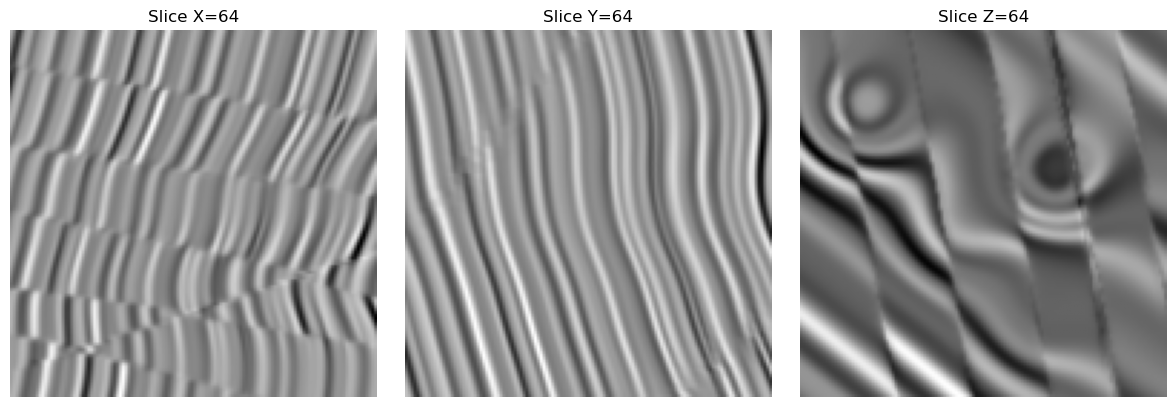

In [8]:
showTile(xTrain[30])

- Exibição Máscaras

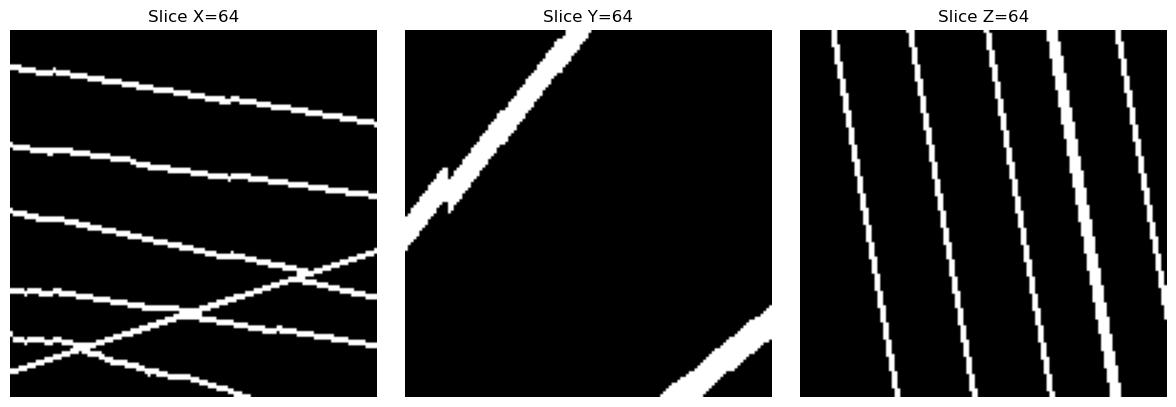

In [9]:
showTile(yTrain[30])

- Alvo (Junção Máscara-Imagem)

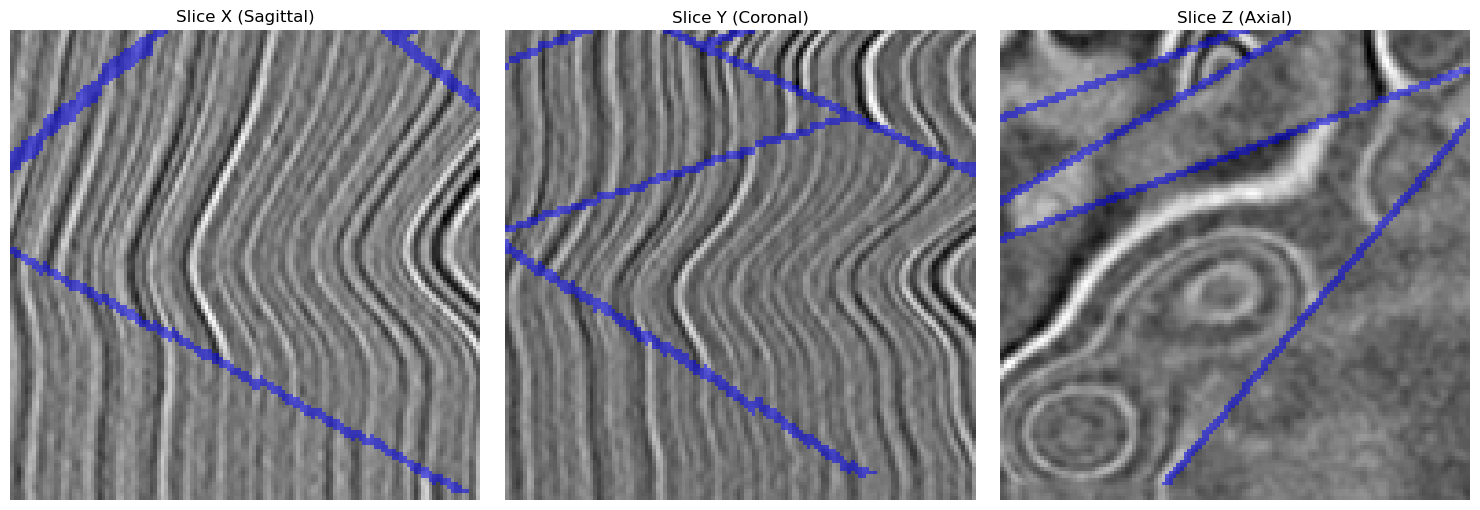

In [10]:
pasteMask(xTrain[0], yTrain[0])

# MODELO

In [11]:
model_options = {
    'network': OPTIONS.get('network'),
    'img_size': OPTIONS.get('img_size'),
    'classes': classes,
    'channels': 1,
    'dropout': OPTIONS.get('dropout'),
    'num_filters': OPTIONS.get('num_filters'),
    'lr': OPTIONS.get('lr'),
}

print(model_options)

network = ModelNetwork(**model_options)
network.model

{'network': 'segresnet', 'img_size': [128, 128, 128], 'classes': 1, 'channels': 1, 'dropout': 0.1, 'num_filters': 16, 'lr': 0.0001}


SegResNet(
  (act_mod): ReLU(inplace=True)
  (convInit): Convolution(
    (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  )
  (down_layers): ModuleList(
    (0): Sequential(
      (0): Identity()
      (1): ResBlock(
        (norm1): GroupNorm(8, 16, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 16, eps=1e-05, affine=True)
        (act): ReLU(inplace=True)
        (conv1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
        (conv2): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
      )
    )
    (1): Sequential(
      (0): Convolution(
        (conv): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (1): ResBlock(
        (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 32, eps=1e-05, a

In [12]:
def getLoader(xData, yData, batch, shuffle=False):
    xTensor = torch.from_numpy(xData).float()
    yTensor = torch.from_numpy(yData).long() if MULTCLASS else torch.from_numpy(yData).float()

    if xTensor.ndim == 4:
        xTensor = xTensor.unsqueeze(1)
    
    if yTensor.ndim == 4: 
        yTensor = yTensor.unsqueeze(1)
    
    dataset = TensorDataset(xTensor, yTensor)
    return DataLoader(dataset, batch_size=batch, shuffle=shuffle, pin_memory=True)


batch_size   = OPTIONS.get('batch_size')
train_loader = getLoader(xTrain, yTrain, batch_size, shuffle=True)
del xTrain, yTrain
val_loader   = getLoader(xVal,   yVal,   batch_size, shuffle=False)
del xVal, yVal

xb, yb = next(iter(train_loader))
print('train X:', xb.shape, xb.dtype) 
print('train Y:', yb.shape, yb.dtype) 

train X: torch.Size([2, 1, 128, 128, 128]) torch.float32
train Y: torch.Size([2, 1, 128, 128, 128]) torch.float32


# FUNÇÃO DE PERDA

In [13]:
from torch import amp
from EarlyStopping.index import EarlyStopping
from Losses.index import Losses

In [14]:
selected_loss = OPTIONS.get('loss')
loss = Losses(selected_loss, multiclass=MULTCLASS)
loss

BinaryDiceFocalLoss(
  (_loss): DiceFocalLoss(
    (dice): DiceLoss()
    (focal): FocalLoss()
  )
)

# SCHEDULER

In [15]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [16]:
class Scheduler:
    def __new__(cls, selected, optimizer):
        if selected == 'plateau':
            return ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        
        if selected == 'cosine':
            return CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
        
        return None


scheduler = OPTIONS.get('scheduler')
Scheduler(scheduler, network.optimizer)

# TREINAMENTO

In [17]:
gc.collect()

6614

In [18]:
class Trainer:
    def __init__(self, network, loss, epochs, scheduler='plateau'):
        self.network  = network
        self.loss     = loss
        self.epochs   = epochs
        self.img_size = network.img_size 
        
        self.scheduler = Scheduler(scheduler, self.network.optimizer)
        self.early_stopping = EarlyStopping(patience=15, mode='max', min_delta=1e-4)

        self.use_amp = False # Geralmente seguro deixar True para 3D
        self.scaler  = amp.GradScaler('cuda', enabled=self.use_amp)

    def start(self):
        self.history = []
        
        for epoch in range(1, self.epochs + 1):
            train_loss, train_iou = self.train()
            val_loss, val_iou     = self.evaluate()

            self.history.append({
                'epoch': epoch,
                'train_loss': train_loss, 'val_loss': val_loss,
                'train_iou': train_iou, 'val_iou': val_iou,
                'lr': self.network.optimizer.param_groups[0]['lr'],
            })
            
            self.scheduler.step(val_loss)
            print(self.history[-1])

            with open(f'Database/progress.json', 'w', encoding='utf-8') as file:
                json.dump(self.history[-1], file, ensure_ascii=False, indent=4)
            
            if self.early_stopping.ready(self.network.model, val_iou):
                break
            
        self.early_stopping.restore_best(self.network.model)

    def train(self, loader=train_loader):
        self.network.model.train()
        self.network.iou.reset()
        train_loss = 0.0

        for (imgs, masks) in loader:
            imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)
            self.network.optimizer.zero_grad()

            # calcular loss
            with amp.autocast('cuda', enabled=self.use_amp):
                logits = self.network.model(imgs)
                loss = self.loss(logits, masks)
            
            train_loss += loss.item()
            self.scaler.scale(loss).backward()
            self.scaler.step(self.network.optimizer)
            self.scaler.update()
            
            # calcular iou
            if self.network.multiclass:
                preds  = torch.argmax(logits, dim=1) 
                target = masks.squeeze(1) if masks.dim() == 5 else masks
                self.network.iou.update(preds, target) 
            else:
                preds = (torch.sigmoid(logits) > 0.5)
                self.network.iou.update(preds, masks.int()) 
        
        # finalizar
        train_loss /= len(loader)
        train_iou  = self.network.iou.compute().item()
        return (train_loss, train_iou)

    def evaluate(self, loader=val_loader):
        self.network.model.eval()
        self.network.iou.reset()
        val_loss = 0.0

        with torch.no_grad():
            for (imgs, masks) in loader:
                imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)

                with amp.autocast('cuda', enabled=self.use_amp):
                    logits = self.network.model(imgs)
                    val_loss += self.loss(logits, masks).item()
                
                if self.network.multiclass:
                    preds  = torch.argmax(logits, dim=1)
                    target = masks.squeeze(1) if masks.dim() == 5 else masks
                    self.network.iou.update(preds, target)
                else:
                    preds = (torch.sigmoid(logits) > 0.5)
                    self.network.iou.update(preds, masks.int())
        
        val_loss /= len(loader)
        val_iou = self.network.iou.compute().item()
        return (val_loss, val_iou)


trainer = Trainer(network, loss, epochs=100, scheduler=scheduler)
trainer.start()

{'epoch': 1, 'train_loss': 0.9322781481526115, 'val_loss': 0.8851732449098066, 'train_iou': 0.10337822884321213, 'val_iou': 0.24598750472068787, 'lr': 0.0001}


{'epoch': 2, 'train_loss': 0.8488902192224156, 'val_loss': 0.8330010717565363, 'train_iou': 0.3198390305042267, 'val_iou': 0.3435145914554596, 'lr': 9.807913967708315e-05}
(earling stopping) model improved to 0.344


{'epoch': 3, 'train_loss': 0.803140252828598, 'val_loss': 0.7906302918087352, 'train_iou': 0.39539992809295654, 'val_iou': 0.41907501220703125, 'lr': 9.829764186744056e-05}
(earling stopping) model improved to 0.419


{'epoch': 4, 'train_loss': 0.7689909745346416, 'val_loss': 0.7571961988102306, 'train_iou': 0.4402763843536377, 'val_iou': 0.4660354256629944, 'lr': 9.846555012934801e-05}
(earling stopping) model improved to 0.466


{'epoch': 5, 'train_loss': 0.7355361689220775, 'val_loss': 0.7263390476053412, 'train_iou': 0.4794665575027466, 'val_iou': 0.4873427748680115, 'lr': 9.859198368793324e-05}
(earling stopping) model improved to 0.487


...

{'epoch': 96, 'train_loss': 0.1389800523492423, 'val_loss': 0.2355876023119146, 'train_iou': 0.8234847187995911, 'val_iou': 0.7279864549636841, 'lr': 9.988228774425768e-05}


{'epoch': 97, 'train_loss': 0.14394307145002214, 'val_loss': 0.21316445957530628, 'train_iou': 0.8178578019142151, 'val_iou': 0.7482035160064697, 'lr': 9.986311799377135e-05}
(earling stopping) model improved to 0.748


{'epoch': 98, 'train_loss': 0.14188913772390646, 'val_loss': 0.221189330924641, 'train_iou': 0.820722222328186, 'val_iou': 0.7401254177093506, 'lr': 9.988792544123695e-05}


{'epoch': 99, 'train_loss': 0.14131749997084792, 'val_loss': 0.22350986979224466, 'train_iou': 0.8212194442749023, 'val_iou': 0.7402514815330505, 'lr': 9.987933165918e-05}


{'epoch': 100, 'train_loss': 0.132174691778015, 'val_loss': 0.22288381240584634, 'train_iou': 0.8323447704315186, 'val_iou': 0.7405815720558167, 'lr': 9.987678751514373e-05}


In [19]:
del train_loader, val_loader

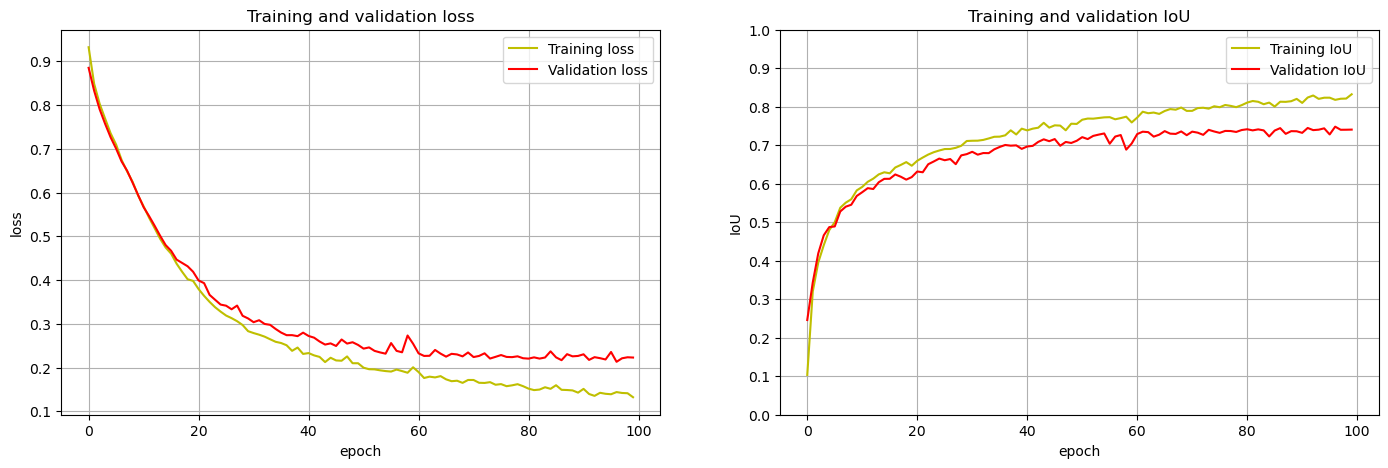

In [20]:
def plotModel(history, save=None):
    plt.figure(figsize=(17, 5))
    plt.subplot(1, 2, 1)
    plt.plot([h.get('train_loss') for h in history], 'y', label='Training loss')
    plt.plot([h.get('val_loss') for h in history], 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'), plt.ylabel('loss')
    plt.legend(), plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.plot([h.get('train_iou') for h in history], 'y', label='Training IoU')
    plt.plot([h.get('val_iou')   for h in history], 'r',  label='Validation IoU')
    plt.title('Training and validation IoU')
    plt.xlabel('epoch'), plt.ylabel('IoU')
    plt.legend(), plt.grid(), plt.gca().set_ylim(0, 1), plt.yticks([c/10 for c in range(11)])
    
    if not save:
        return plt.show()

    os.makedirs(os.path.dirname(save), exist_ok=True)
    plt.savefig(save, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()


plotModel(trainer.history)

# DADOS DE TESTE

In [21]:
xTest = np.array([np.load(path) for path in getFiles('Database/Processed/test/images')])
yTest = np.array([np.load(path) for path in getFiles('Database/Processed/test/masks')])

test_loader = getLoader(xTest,  yTest, 1, shuffle=False)
test_loss, test_iou = trainer.evaluate(test_loader)
test_iou

0.7708293795585632

# SALVANDO O MODELO

In [22]:
from datetime import datetime
import json, inspect

In [23]:
os.makedirs('Backup/', exist_ok=True)
files   = os.listdir('Backup/')
indexes = sorted([int(path.split('_')[-1]) for path in files]) if len(files) > 0 else [0]
index  = indexes[-1] + 1
folder = f'Backup/model_{index}'
os.makedirs(folder, exist_ok=True)
folder

'Backup/model_13'

In [24]:
model_info = {
    'trainer': {
        'path': f'model_{index}',
        'loss': selected_loss,
        'scheduler': scheduler,
        'epochs': trainer.epochs,
        'batch_size': OPTIONS.get('batch_size'),
        'val_iou':  trainer.history[-1].get('val_iou'),
        'test_iou': test_iou,
    },

    'processing': processing_options,
    'model': model_options
}

model_data = {
    'model': network.model.state_dict(),
    'optimizer': network.optimizer.state_dict(),
    'timestamp': datetime.now().strftime('%d/%m/%y %H:%M:%S'),
    'history': trainer.history,
}

with open(f'{folder}/info.json', 'w', encoding='utf-8') as file:
    json.dump(model_info, file, ensure_ascii=False, indent=4)

plotModel(model_data['history'], f'{folder}/train.png')
torch.save(model_data, f'{folder}/data.pth')
print('model saved in', folder)

model saved in Backup/model_13
